In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git config --global user.email "spoorthyece@gmail.com"
!git config --global user.name "Spoorthy2001"

# Predictive Maintenance (AI4I 2020)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import StandardScaler

print("All import successfulL")
np.random.seed(42)

All import successfulL


## MLFlow setup

In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("AI4I_Predictive_Maintenance")

print("MLFlow Version : ", mlflow.__version__)
print("Experiment set")

2026/05/24 17:00:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/24 17:00:38 INFO mlflow.store.db.utils: Updating database tables
2026/05/24 17:00:44 INFO mlflow.tracking.fluent: Experiment with name 'AI4I_Predictive_Maintenance' does not exist. Creating a new experiment.


MLFlow Version :  3.12.0
Experiment set


## Importing dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")

100%|██████████| 136k/136k [00:00<00:00, 315kB/s]

Extracting files...


## Little dig into Domain knowledge

### Failure Modes

TWF → Tool Wear Failure — tool degrades past threshold
HDF → Heat Dissipation Failure — cooling system overwhelmed
PWF → Power Failure — outside 3500-9000W operating window
OSF → Overstrain Failure — torque × wear exceeds limit
RNF → Random Failure — unpredictable, 0.1% probability
Machine Failure → 1 if ANY above occurs

| Feature | Which failure it drives |
|---|---|
| Air temperature      | HDF (cooling capacity) |
| Process temperature  | HDF (heat generated) |
| Rotational speed     | HDF + PWF |
| Torque               | PWF + OSF |
| Tool wear            | TWF + OSF |
| Product quality (L/M/H) | TWF + OSF thresholds |

In [ ]:
df = pd.read_csv(f'{path}/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Feature Analysis

### Shape and schema

In [ ]:
print("Shape : ", df.shape)
print("Columns to list :", df.columns.to_list())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Shape :  (10000, 14)
Columns to list : ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Data types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
M

### Target Distribution

In [ ]:
print("Machine failure distribution:")
print(df['Machine failure'].value_counts())
print(f"\nFailure rate: {df['Machine failure'].mean()*100:.2f}%")

Machine failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


### Failure Modes

In [ ]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Individual failure mode counts:")
print(df[failure_cols].sum())
print(f"\nTotal Failure count of non Machinery failures:", df[failure_cols].sum().sum())

Individual failure mode counts:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Total Failure count of non Machinery failures: 373


## Imbalance problem in Target variable
### Visuvalizing the same

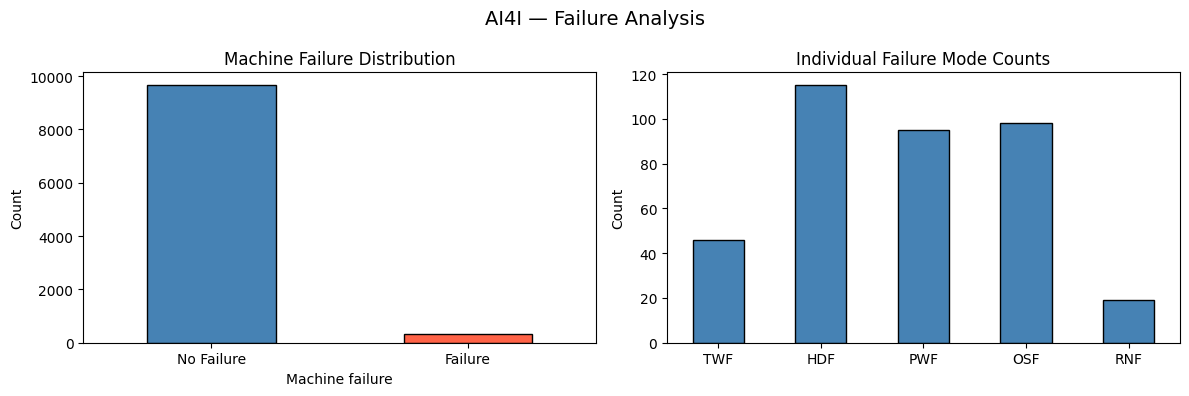

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
df['Machine failure'].value_counts().plot(kind='bar', ax=axes[0],color=['steelblue', 'tomato'],edgecolor='black')
axes[0].set_title("Machine Failure Distribution")
axes[0].set_xticklabels(['No Failure', 'Failure'], rotation=0)
axes[0].set_ylabel("Count")

# Failure modes
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df[failure_cols].sum().plot(kind='bar', ax=axes[1],color='steelblue', edgecolor='black')
axes[1].set_title("Individual Failure Mode Counts")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle("AI4I — Failure Analysis", fontsize=14)
plt.tight_layout()
plt.show()

## Feature Engineering

### Create 2 new columns.
1. Power
2. Temperature difference

In [ ]:
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Torque [Nm]'] * (df['Rotational speed [rpm]'] * 2 * np.pi/60)

In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_diff,Power
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608


In [ ]:
df[['temp_diff', 'Power']].describe()

,temp_diff,Power
count,10000.000000,10000.000000
mean,10.000630,6279.744953
std,1.001094,1067.418295
min,7.600000,1148.440610
25%,9.300000,5561.184484
50%,9.800000,6271.027344
75%,11.000000,7003.002724
max,12.100000,10469.923005


In [ ]:
drop_columns = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

X = df.drop(drop_columns + ['Machine failure'], axis=1)
y = df['Machine failure']

#Encoding the categorical column

X = pd.get_dummies(X, columns=['Type'], drop_first=True)

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (10000, 9)
Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'Power', 'Type_L', 'Type_M']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining failure rate:", y_train.mean().round(4))
print("Test failure rate:", y_test.mean().round(4))

Training set: (8000, 9)
Test set: (2000, 9)

Training failure rate: 0.0339
Test failure rate: 0.034


### Model 01:
1. Algorithm - Random Forest

In [ ]:
model_1 = RandomForestClassifier(n_estimators=100, random_state=42)
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print("Model 1 - Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_1))
print("Classification Report:\n", classification_report(y_test, y_pred_1))

Model 1 - Random Forest
Accuracy: 0.991
Confusion Matrix:
 [[1928    4]
 [  14   54]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.79      0.86        68

    accuracy                           0.99      2000
   macro avg       0.96      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



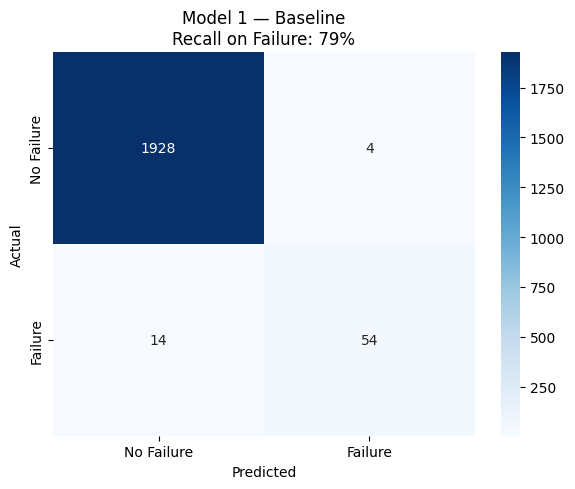

In [ ]:
# PLotting confusion matrix

cm = confusion_matrix(y_test, y_pred_1)
classification_report_random_forest = classification_report(y_test, y_pred_1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.title(f"Model 1 — Baseline\nRecall on Failure: 79%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Handling Imbalance - SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


### Model 02 - After applying SMOTE to the data

In [ ]:
model_2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_2.fit(X_train_smote, y_train_smote)

y_pred_2 = model_2.predict(X_test)

# print("Model 2 - Random Forest")
# print("Accuracy:", accuracy_score(y_test, y_pred_2))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_2))
# print("Classification Report:\n", classification_report(y_test, y_pred_2))

print("--- Model 2 --- Random Forest + SMOTE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_2):.4f}")
print(classification_report(y_test, y_pred_2,
      target_names=['No Failure', 'Failure']))

--- Model 2 --- Random Forest + SMOTE ---
Accuracy: 0.9740
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.59      0.78      0.67        68

    accuracy                           0.97      2000
   macro avg       0.79      0.88      0.83      2000
weighted avg       0.98      0.97      0.98      2000



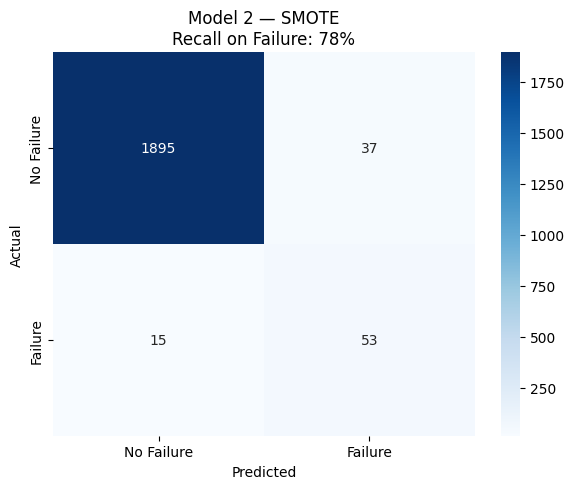

In [ ]:
cm2 = confusion_matrix(y_test, y_pred_2)

plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.title("Model 2 — SMOTE\nRecall on Failure: 78%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Model 03 - with class_weight

In [ ]:
model_3 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_3.fit(X_train, y_train)

y_pred_3 = model_3.predict(X_test)

print("Model 3 - Random Forest + Class Weight")
print("Accuracy:", accuracy_score(y_test, y_pred_3))
print("Classification Report:\n", classification_report(y_test, y_pred_3))

Model 3 - Random Forest + Class Weight
Accuracy: 0.989
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.72      0.82        68

    accuracy                           0.99      2000
   macro avg       0.97      0.86      0.91      2000
weighted avg       0.99      0.99      0.99      2000



### Model 04 - Training with XGBoost

In [ ]:
#formated X, removed string characters
X_clean = X.copy()
X_clean.columns = X_clean.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace(' ', '_', regex=False)
# X_clean = X_clean.drop(['Rotational_speed_rpm', 'Torque_Nm'], axis=1)
print(X_clean.columns.tolist())

['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'temp_diff', 'Power', 'Type_L', 'Type_M']


In [ ]:
from xgboost import XGBClassifier

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean, y, test_size=0.2, random_state=42, stratify=y)

# scale_pos_weight = negative/positive = 7729/271 ≈ 28.5
model_4 = XGBClassifier(n_estimators=100,
                         scale_pos_weight=28.5,
                         random_state=42,
                         eval_metric='logloss')
model_4.fit(X_train_clean, y_train_clean)
y_pred_4 = model_4.predict(X_test_clean)

print("--- Model 4 --- XGBoost + scale_pos_weight ---")
print(f"Accuracy: {accuracy_score(y_test_clean, y_pred_4):.4f}")
print(classification_report(y_test_clean, y_pred_4,
      target_names=['No Failure', 'Failure']))

--- Model 4 --- XGBoost + scale_pos_weight ---
Accuracy: 0.9875
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.81      0.82      0.82        68

    accuracy                           0.99      2000
   macro avg       0.90      0.91      0.91      2000
weighted avg       0.99      0.99      0.99      2000



In [ ]:
# Get probabilities instead of hard predictions
y_prob_4 = model_4.predict_proba(X_test_clean)[:, 1]

# Try lower threshold
threshold = 0.2
y_pred_threshold = (y_prob_4 >= threshold).astype(int)

print(f"--- Model 4 --- Threshold = {threshold} ---")
print(f"Accuracy: {accuracy_score(y_test_clean, y_pred_threshold):.4f}")
print(classification_report(y_test_clean, y_pred_threshold, target_names=['No Failure', 'Failure']))

--- Model 4 --- Threshold = 0.2 ---
Accuracy: 0.9825
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.71      0.82      0.76        68

    accuracy                           0.98      2000
   macro avg       0.85      0.91      0.88      2000
weighted avg       0.98      0.98      0.98      2000



In [ ]:
from sklearn.metrics import recall_score, precision_score

print("Threshold | Recall | Precision | False Alarms")
print("─" * 50)
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_t = (y_prob_4 >= t).astype(int)
    r = recall_score(y_test_clean, y_t)
    p = precision_score(y_test_clean, y_t)
    fa = sum((y_t == 1) & (y_test_clean == 0))
    print(f"  {t}       | {r:.2f}   | {p:.2f}      | {fa}")

Threshold | Recall | Precision | False Alarms
──────────────────────────────────────────────────
  0.1       | 0.82   | 0.64      | 31
  0.2       | 0.82   | 0.71      | 23
  0.3       | 0.82   | 0.77      | 17
  0.4       | 0.82   | 0.80      | 14
  0.5       | 0.82   | 0.81      | 13


### Feature Importance

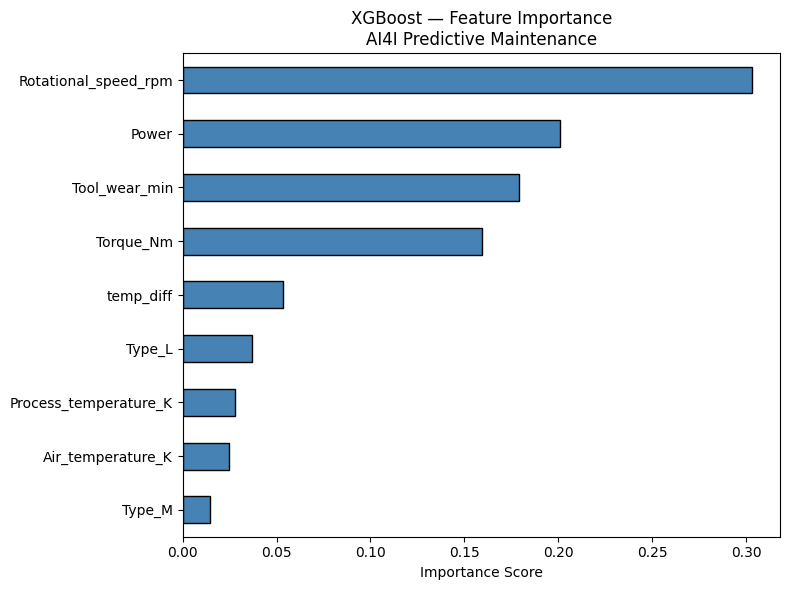

In [ ]:
importance_4 = pd.Series(model_4.feature_importances_,
                          index=X_clean.columns)
importance_4.sort_values().plot(kind='barh',
                                 figsize=(8, 6),
                                 color='steelblue',
                                 edgecolor='black')
plt.title("XGBoost — Feature Importance\nAI4I Predictive Maintenance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
!pip install mlflow --quiet

## Implementing MLOps

In [ ]:
with mlflow.start_run(run_name="Baseline_RandomForest"):
  mlflow.log_param("model", "RandomForest")
  mlflow.log_param("n_estimatmator", 100)
  mlflow.log_param("class_weight", None)
  mlflow.log_param("SMOTE", False)

  model_1 = RandomForestClassifier(n_estimators=100, random_state=42)
  model_1.fit(X_train, y_train)

  y_pred_1 = model_1.predict(X_test)

  mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_1))
  mlflow.log_metric("Recall score", recall_score(y_test, y_pred_1))
  mlflow.log_metric("Precision score", precision_score(y_test, y_pred_1))
  mlflow.log_metric("F1 score", f1_score(y_test, y_pred_1))

  mlflow.sklearn.log_model(model_1, "model")
  print("Run logged.")
  print(f"Recall score :{recall_score(y_test, y_pred_1):.4f}")

2026/05/24 17:01:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:01:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged.
Recall score :0.7941


In [ ]:
models_to_log = [
    {
        "run_name": "Baseline_RandomForest",
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "X_train": X_train, "y_train": y_train,
        "X_test": X_test, "y_test": y_test,
        "params": {"n_estimators": 100, "SMOTE": False, "class_weight": "None"}
    },
    {
        "run_name": "RandomForest_SMOTE",
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "X_train": X_train_smote, "y_train": y_train_smote,
        "X_test": X_test, "y_test": y_test,
        "params": {"n_estimators": 100, "SMOTE": True, "class_weight": "None"}
    },
    {
        "run_name": "RandomForest_ClassWeight",
        "model": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        "X_train": X_train, "y_train": y_train,
        "X_test": X_test, "y_test": y_test,
        "params": {"n_estimators": 100, "SMOTE": False, "class_weight": "balanced"}
    },
    {
        "run_name": "XGBoost_ScalePosWeight",
        "model": XGBClassifier(n_estimators=100, scale_pos_weight=28.5,
                               random_state=42, eval_metric='logloss'),
        "X_train": X_train_clean, "y_train": y_train,    # ← X_train_c
        "X_test": X_test_clean, "y_test": y_test,         # ← X_test_c
        "params": {"n_estimators": 100, "scale_pos_weight": 28.5, "SMOTE": False}
    },
]

for m in models_to_log:
    with mlflow.start_run(run_name=m["run_name"]):
        mlflow.log_params(m["params"])
        m["model"].fit(m["X_train"], m["y_train"])
        y_pred = m["model"].predict(m["X_test"])

        mlflow.log_metric("accuracy", round(accuracy_score(m["y_test"], y_pred), 4))
        mlflow.log_metric("recall", round(recall_score(m["y_test"], y_pred), 4))
        mlflow.log_metric("precision", round(precision_score(m["y_test"], y_pred), 4))
        mlflow.log_metric("f1", round(f1_score(m["y_test"], y_pred), 4))
        mlflow.sklearn.log_model(m["model"], "model")

        print(f"{m['run_name']} → Recall: {recall_score(m['y_test'], y_pred):.4f}")

2026/05/24 17:02:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:02:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline_RandomForest → Recall: 0.7941


2026/05/24 17:03:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:03:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest_SMOTE → Recall: 0.7794


2026/05/24 17:03:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:03:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest_ClassWeight → Recall: 0.7206


2026/05/24 17:03:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:03:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost_ScalePosWeight → Recall: 0.8235


In [ ]:
#Best run

# Get the best run ID
best_run = mlflow.search_runs(
    experiment_names=["AI4I_Predictive_Maintenance"],
    order_by=["metrics.recall DESC"]
).iloc[0]

print("Best run:")
print(f"  Name   : {best_run['tags.mlflow.runName']}")
print(f"  Recall : {best_run['metrics.recall']}")
print(f"  Run ID : {best_run['run_id']}")

# Register the model
model_uri = f"runs:/{best_run['run_id']}/model"
mlflow.register_model(model_uri, "AI4I_BestModel")

print("\nModel registered successfully.")

Best run:
  Name   : XGBoost_ScalePosWeight
  Recall : 0.8235
  Run ID : 123268ace47d436f90f85d804f009b8e


Successfully registered model 'AI4I_BestModel'.
2026/05/24 17:05:05 WARNING mlflow.tracking._model_registry.fluent: Run with id 123268ace47d436f90f85d804f009b8e has no artifacts at artifact path 'model', registering model based on models:/m-9183681c255f4310b24532e90cfff3c7 instead



Model registered successfully.


Created version '1' of model 'AI4I_BestModel'.


In [1]:
from google.colab import files
import joblib

joblib.dump(poly, 'energy.joblib')
files.download('energy.joblib')

NameError: name 'poly' is not defined